In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
os.chdir("..")

## UMAP — Type 3 Hard Contrastive Negatives in Embedding Space
Visualizes where contrastive hard negatives land relative to real positives
and negatives. Key question: do they cluster near the positive-negative boundary
as intended, or scatter widely? This directly informs whether contrastive
augmentation will sharpen the decision boundary.
Three colors: real negatives (blue), real positives (red), type 3 contrastive negatives (green).

In [5]:
import umap
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

# Load saved embeddings
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")

# Load and encode contrastive negatives
df_contrastive = pd.read_parquet("data/synthetic/hard_contrastive_raw.parquet")
print(f"Contrastive negatives: {len(df_contrastive)}")

model = SentenceTransformer('all-MiniLM-L6-v2')
print("Encoding contrastive negatives...")
X_contrastive = model.encode(df_contrastive['sentence'].tolist(), show_progress_bar=True)
print(f"Contrastive embeddings: {X_contrastive.shape}")

# Same sampling as notebook 04 — seed 42, 2000 negatives, all positives
np.random.seed(42)
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]
neg_sample_idx = np.random.choice(neg_idx, size=2000, replace=False)

print(f"\nReal positives: {len(pos_idx)}")
print(f"Real negatives (sampled): {len(neg_sample_idx)}")
print(f"Contrastive negatives: {len(X_contrastive)}")

# Stack for UMAP
X_umap = np.vstack([
    X_train[pos_idx],
    X_train[neg_sample_idx],
    X_contrastive
])

labels = np.array(
    ['Real Positive'] * len(pos_idx) +
    ['Real Negative'] * len(neg_sample_idx) +
    ['Contrastive Negative'] * len(X_contrastive)
)

print("\nFitting UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
embedding = reducer.fit_transform(X_umap)
print("Done.")

Contrastive negatives: 1342


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 752.42it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding contrastive negatives...


Batches: 100%|██████████| 42/42 [00:03<00:00, 11.60it/s]
c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Contrastive embeddings: (1342, 384)

Real positives: 674
Real negatives (sampled): 2000
Contrastive negatives: 1342

Fitting UMAP...
Done.


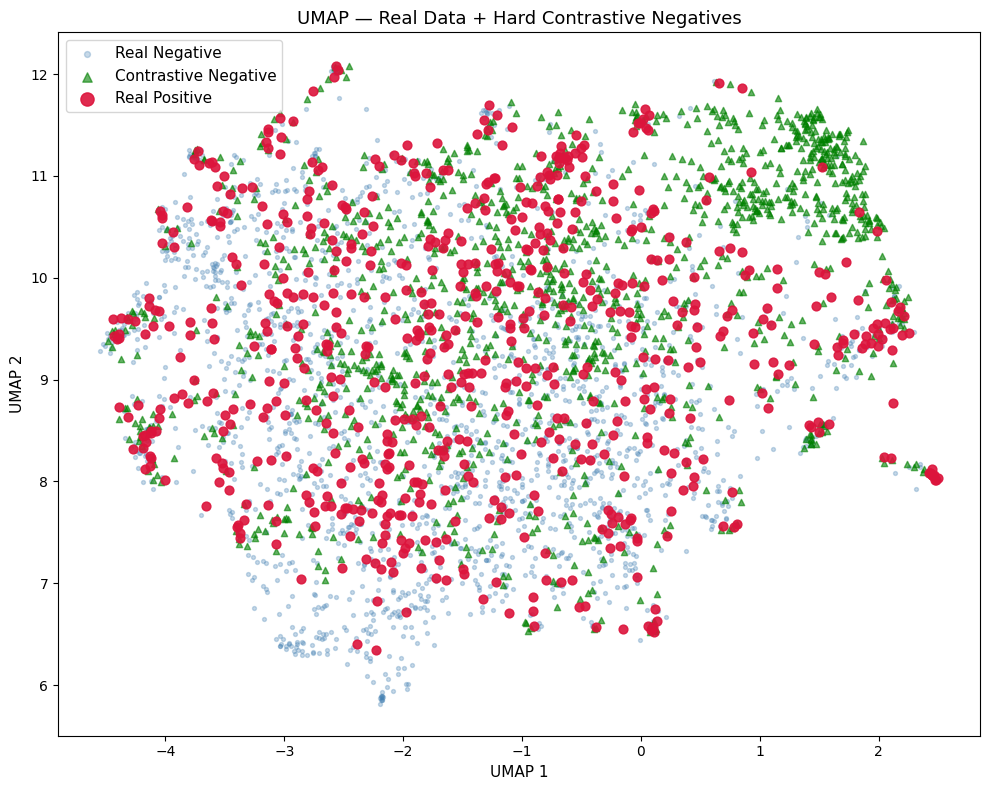

Saved.


In [6]:
color_map = {
    'Real Negative': 'steelblue',
    'Real Positive': 'crimson',
    'Contrastive Negative': 'green'
}

marker_map = {
    'Real Negative': 'o',
    'Real Positive': 'o',
    'Contrastive Negative': '^'
}

size_map = {
    'Real Negative': 8,
    'Real Positive': 40,
    'Contrastive Negative': 20
}

alpha_map = {
    'Real Negative': 0.3,
    'Real Positive': 0.9,
    'Contrastive Negative': 0.6
}

fig, ax = plt.subplots(figsize=(10, 8))

for label in ['Real Negative', 'Contrastive Negative', 'Real Positive']:
    mask = labels == label
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        c=color_map[label],
        marker=marker_map[label],
        s=size_map[label],
        alpha=alpha_map[label],
        label=label
    )

ax.set_title('UMAP — Real Data + Hard Contrastive Negatives', fontsize=13)
ax.legend(fontsize=11, markerscale=1.5)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
plt.tight_layout()
plt.savefig("data/results/umap_hard_contrastive_negatives.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## Baseline Classifier
Retrained in this session to ensure Venn-Abers calibrated scores are directly
comparable across all conditions evaluated in this notebook.
Same hyperparameters as all previous experiments.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from venn_abers import VennAbersCalibrator
import json

# Load all embeddings
X_cal = np.load("data/processed/embeddings/X_cal.npy")
y_cal = np.load("data/processed/embeddings/y_cal.npy")
X_test = np.load("data/processed/embeddings/X_test.npy")
y_test = np.load("data/processed/embeddings/y_test.npy")

# Train baseline
clf_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_base.fit(X_train, y_train)
print("Baseline classifier trained.")

# Venn-Abers calibration
va_base = VennAbersCalibrator(estimator=clf_base, inductive=True, cal_size=None)
va_base.fit(X_cal, y_cal)
print("Venn-Abers calibrator fitted.")

# Scores
y_scores_base = clf_base.predict_proba(X_test)[:, 1]
y_pred_base = clf_base.predict(X_test)
y_scores_base_cal = va_base.predict_proba(X_test)[:, 1]

print(f"\nRaw score range:        [{y_scores_base.min():.3f}, {y_scores_base.max():.3f}]")
print(f"Calibrated score range: [{y_scores_base_cal.min():.3f}, {y_scores_base_cal.max():.3f}]")

# Threshold optimization function
def optimal_threshold_f1(y_true, y_scores, thresholds=np.arange(0.01, 0.70, 0.01)):
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

# Metrics
t_base, _ = optimal_threshold_f1(y_test, y_scores_base_cal)
y_pred_base_cal = (y_scores_base_cal >= t_base).astype(int)

print("\n=== Baseline — Raw (threshold=0.5) ===")
print(classification_report(y_test, y_pred_base, digits=3))
print(f"=== Baseline — Calibrated (threshold={t_base:.2f}) ===")
print(classification_report(y_test, y_pred_base_cal, digits=3))

# Save metrics
os.makedirs("data/results", exist_ok=True)
baseline_metrics = {
    "baseline": {
        "raw": {
            "threshold": 0.5,
            "precision": round(precision_score(y_test, y_pred_base, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_base), 3),
            "f1": round(f1_score(y_test, y_pred_base, zero_division=0), 3),
        },
        "calibrated": {
            "threshold": round(t_base, 2),
            "precision": round(precision_score(y_test, y_pred_base_cal, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_base_cal), 3),
            "f1": round(f1_score(y_test, y_pred_base_cal, zero_division=0), 3),
        }
    }
}

with open("data/results/hard_contrastive_baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)
print("\nSaved to data/results/hard_contrastive_baseline_metrics.json")

Baseline classifier trained.
Venn-Abers calibrator fitted.

Raw score range:        [0.000, 0.999]
Calibrated score range: [0.002, 0.667]

=== Baseline — Raw (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.998     0.869     0.929     19669
           1      0.059     0.839     0.110       192

    accuracy                          0.869     19861
   macro avg      0.529     0.854     0.520     19861
weighted avg      0.989     0.869     0.921     19861

=== Baseline — Calibrated (threshold=0.07) ===
              precision    recall  f1-score   support

           0      0.993     0.984     0.988     19669
           1      0.136     0.260     0.179       192

    accuracy                          0.977     19861
   macro avg      0.564     0.622     0.583     19861
weighted avg      0.984     0.977     0.980     19861


Saved to data/results/hard_contrastive_baseline_metrics.json


## Unfiltered Contrastive Augmentation
All 1,342 Type 3 hard contrastive negatives added to training set without filtering.
Imbalance ratio will increase slightly as we're adding negatives, not positives.

In [8]:
# Build unfiltered contrastive augmented train set
X_train_cont = np.vstack([X_train, X_contrastive])
y_train_cont = np.concatenate([y_train, np.zeros(len(X_contrastive), dtype=int)])

print(f"Original train:              {X_train.shape} | Positives: {y_train.sum()}")
print(f"Contrastive augmented train: {X_train_cont.shape} | Positives: {y_train_cont.sum()}")
print(f"Imbalance ratio: {(y_train_cont==0).sum()/y_train_cont.sum():.1f}:1")

# Train
clf_cont = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_cont.fit(X_train_cont, y_train_cont)
print("\nUnfiltered contrastive classifier trained.")

# Venn-Abers
va_cont = VennAbersCalibrator(estimator=clf_cont, inductive=True, cal_size=None)
va_cont.fit(X_cal, y_cal)
print("Venn-Abers calibrator fitted.")

# Scores
y_scores_cont = clf_cont.predict_proba(X_test)[:, 1]
y_pred_cont = clf_cont.predict(X_test)
y_scores_cont_cal = va_cont.predict_proba(X_test)[:, 1]

print(f"\nRaw score range:        [{y_scores_cont.min():.3f}, {y_scores_cont.max():.3f}]")
print(f"Calibrated score range: [{y_scores_cont_cal.min():.3f}, {y_scores_cont_cal.max():.3f}]")

# Metrics
t_cont, _ = optimal_threshold_f1(y_test, y_scores_cont_cal)
y_pred_cont_cal = (y_scores_cont_cal >= t_cont).astype(int)

print("\n=== Unfiltered Contrastive — Raw (threshold=0.5) ===")
print(classification_report(y_test, y_pred_cont, digits=3))
print(f"=== Unfiltered Contrastive — Calibrated (threshold={t_cont:.2f}) ===")
print(classification_report(y_test, y_pred_cont_cal, digits=3))

Original train:              (69510, 384) | Positives: 674
Contrastive augmented train: (70852, 384) | Positives: 674
Imbalance ratio: 104.1:1

Unfiltered contrastive classifier trained.
Venn-Abers calibrator fitted.

Raw score range:        [0.000, 0.999]
Calibrated score range: [0.001, 0.556]

=== Unfiltered Contrastive — Raw (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.998     0.870     0.930     19669
           1      0.059     0.839     0.111       192

    accuracy                          0.870     19861
   macro avg      0.529     0.854     0.520     19861
weighted avg      0.989     0.870     0.922     19861

=== Unfiltered Contrastive — Calibrated (threshold=0.11) ===
              precision    recall  f1-score   support

           0      0.992     0.984     0.988     19669
           1      0.120     0.219     0.155       192

    accuracy                          0.977     19861
   macro avg      0.556     0.602     0.571 

In [9]:
cont_metrics = {
    "unfiltered_contrastive": {
        "raw": {
            "threshold": 0.5,
            "precision": round(precision_score(y_test, y_pred_cont, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_cont), 3),
            "f1": round(f1_score(y_test, y_pred_cont, zero_division=0), 3),
        },
        "calibrated": {
            "threshold": round(t_cont, 2),
            "precision": round(precision_score(y_test, y_pred_cont_cal, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_cont_cal), 3),
            "f1": round(f1_score(y_test, y_pred_cont_cal, zero_division=0), 3),
        }
    }
}

with open("data/results/hard_contrastive_unfiltered_metrics.json", "w") as f:
    json.dump(cont_metrics, f, indent=2)
print("Saved.")

Saved.


## Calibrated Filtering of Contrastive Negatives
Filtering direction is REVERSED relative to positive augmentation.
We want LOW calibrated score (classifier correctly identifies as non-hedge)
and NARROW interval width (confident rejection).
High-scoring contrastive negatives are dangerous — they look like hedges
to the classifier and would add noise rather than sharpen the boundary.

Calibrated score range: [0.0029, 0.6667]
Interval width range:   [0.0010, 0.9355]
Mean calibrated score:  0.0635
Mean interval width:    0.0351


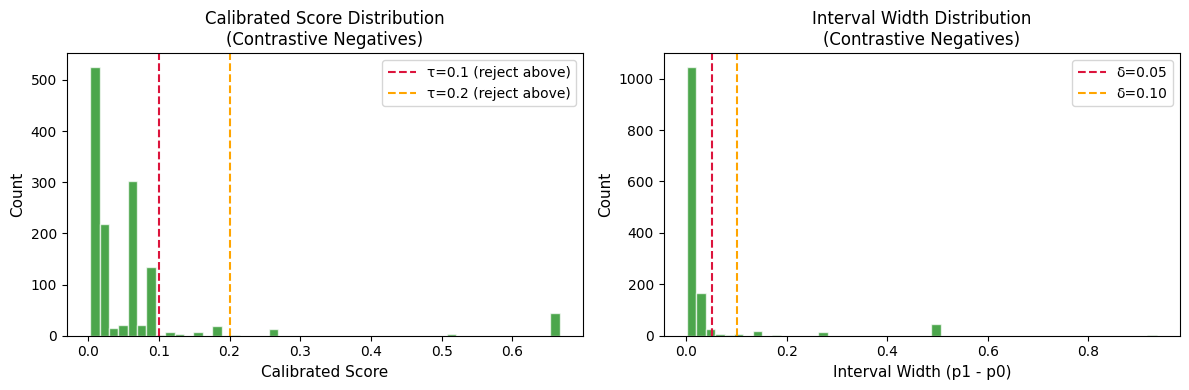

Saved.


In [10]:
# Get calibrated scores and intervals for contrastive negatives
p_prime_cont, p0p1_cont = va_base.va_calibrator.predict_proba(
    X_contrastive, p0_p1_output=True
)

p_cal_cont = p_prime_cont[:, 1]
p0p1_cont_arr = p0p1_cont[0]
p0_cont = p0p1_cont_arr[:, 0]
p1_cont = p0p1_cont_arr[:, 1]
interval_widths_cont = p1_cont - p0_cont

print(f"Calibrated score range: [{p_cal_cont.min():.4f}, {p_cal_cont.max():.4f}]")
print(f"Interval width range:   [{interval_widths_cont.min():.4f}, {interval_widths_cont.max():.4f}]")
print(f"Mean calibrated score:  {p_cal_cont.mean():.4f}")
print(f"Mean interval width:    {interval_widths_cont.mean():.4f}")

# Plot distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(p_cal_cont, bins=50, color='green', edgecolor='white', alpha=0.7)
ax1.axvline(x=0.1, color='crimson', linestyle='--', label='τ=0.1 (reject above)')
ax1.axvline(x=0.2, color='orange', linestyle='--', label='τ=0.2 (reject above)')
ax1.set_xlabel('Calibrated Score', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Calibrated Score Distribution\n(Contrastive Negatives)', fontsize=12)
ax1.legend(fontsize=10)

ax2.hist(interval_widths_cont, bins=50, color='green', edgecolor='white', alpha=0.7)
ax2.axvline(x=0.05, color='crimson', linestyle='--', label='δ=0.05')
ax2.axvline(x=0.10, color='orange', linestyle='--', label='δ=0.10')
ax2.set_xlabel('Interval Width (p1 - p0)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Interval Width Distribution\n(Contrastive Negatives)', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("data/results/hard_contrastive_score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [11]:
thresholds = [(0.1, 0.05), (0.1, 0.10), (0.2, 0.05), (0.2, 0.10)]

print(f"Total contrastive negatives: {len(p_cal_cont)}")
print(f"\n{'τ (score)':>12} {'δ (width)':>12} {'Survivors':>12} {'Pass rate':>12}")
print("-" * 52)
for tau, delta in thresholds:
    mask = (p_cal_cont <= tau) & (interval_widths_cont <= delta)
    n = mask.sum()
    print(f"{tau:>12.2f} {delta:>12.2f} {n:>12} {n/len(p_cal_cont)*100:>11.1f}%")

Total contrastive negatives: 1342

   τ (score)    δ (width)    Survivors    Pass rate
----------------------------------------------------
        0.10         0.05         1240        92.4%
        0.10         0.10         1240        92.4%
        0.20         0.05         1242        92.5%
        0.20         0.10         1253        93.4%


In [12]:
filter_mask_hard = (p_cal_cont <= 0.10) & (interval_widths_cont <= 0.05)
X_hard_filtered = X_contrastive[filter_mask_hard]
y_hard_filtered = np.zeros(filter_mask_hard.sum(), dtype=int)
df_hard_filtered = df_contrastive[filter_mask_hard].reset_index(drop=True)

print(f"Survivors: {filter_mask_hard.sum()}")
print(f"Rejected (too hedge-like): {(~filter_mask_hard).sum()}")
print(f"\nRejected score range: [{p_cal_cont[~filter_mask_hard].min():.3f}, "
      f"{p_cal_cont[~filter_mask_hard].max():.3f}]")
print(f"Rejected type distribution:\n"
      f"{df_contrastive[~filter_mask_hard]['contrastive_type'].value_counts()}")

Survivors: 1240
Rejected (too hedge-like): 102

Rejected score range: [0.106, 0.667]
Rejected type distribution:
contrastive_type
subtype_b    89
subtype_a    13
Name: count, dtype: int64


In [13]:
# Build filtered hard contrastive augmented train set
X_train_hard_filt = np.vstack([X_train, X_hard_filtered])
y_train_hard_filt = np.concatenate([y_train, y_hard_filtered])

print(f"Original train:              {X_train.shape} | Positives: {y_train.sum()}")
print(f"Filtered hard contrastive:   {X_train_hard_filt.shape} | Positives: {y_train_hard_filt.sum()}")
print(f"Imbalance ratio: {(y_train_hard_filt==0).sum()/y_train_hard_filt.sum():.1f}:1")

# Train
clf_hard_filt = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_hard_filt.fit(X_train_hard_filt, y_train_hard_filt)
print("\nFiltered hard contrastive classifier trained.")

# Venn-Abers
va_hard_filt = VennAbersCalibrator(estimator=clf_hard_filt, inductive=True, cal_size=None)
va_hard_filt.fit(X_cal, y_cal)
print("Venn-Abers calibrator fitted.")

# Scores
y_scores_hard_filt = clf_hard_filt.predict_proba(X_test)[:, 1]
y_pred_hard_filt = clf_hard_filt.predict(X_test)
y_scores_hard_filt_cal = va_hard_filt.predict_proba(X_test)[:, 1]

print(f"\nRaw score range:        [{y_scores_hard_filt.min():.3f}, {y_scores_hard_filt.max():.3f}]")
print(f"Calibrated score range: [{y_scores_hard_filt_cal.min():.3f}, {y_scores_hard_filt_cal.max():.3f}]")

# Metrics
t_hard_filt, _ = optimal_threshold_f1(y_test, y_scores_hard_filt_cal)
y_pred_hard_filt_cal = (y_scores_hard_filt_cal >= t_hard_filt).astype(int)

print("\n=== Filtered Hard Contrastive — Raw (threshold=0.5) ===")
print(classification_report(y_test, y_pred_hard_filt, digits=3))
print(f"=== Filtered Hard Contrastive — Calibrated (threshold={t_hard_filt:.2f}) ===")
print(classification_report(y_test, y_pred_hard_filt_cal, digits=3))

Original train:              (69510, 384) | Positives: 674
Filtered hard contrastive:   (70750, 384) | Positives: 674
Imbalance ratio: 104.0:1

Filtered hard contrastive classifier trained.
Venn-Abers calibrator fitted.

Raw score range:        [0.000, 0.999]
Calibrated score range: [0.001, 0.583]

=== Filtered Hard Contrastive — Raw (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.998     0.870     0.930     19669
           1      0.059     0.833     0.110       192

    accuracy                          0.870     19861
   macro avg      0.529     0.852     0.520     19861
weighted avg      0.989     0.870     0.922     19861

=== Filtered Hard Contrastive — Calibrated (threshold=0.13) ===
              precision    recall  f1-score   support

           0      0.992     0.992     0.992     19669
           1      0.173     0.167     0.170       192

    accuracy                          0.984     19861
   macro avg      0.582     0.579  

Metrics saved.


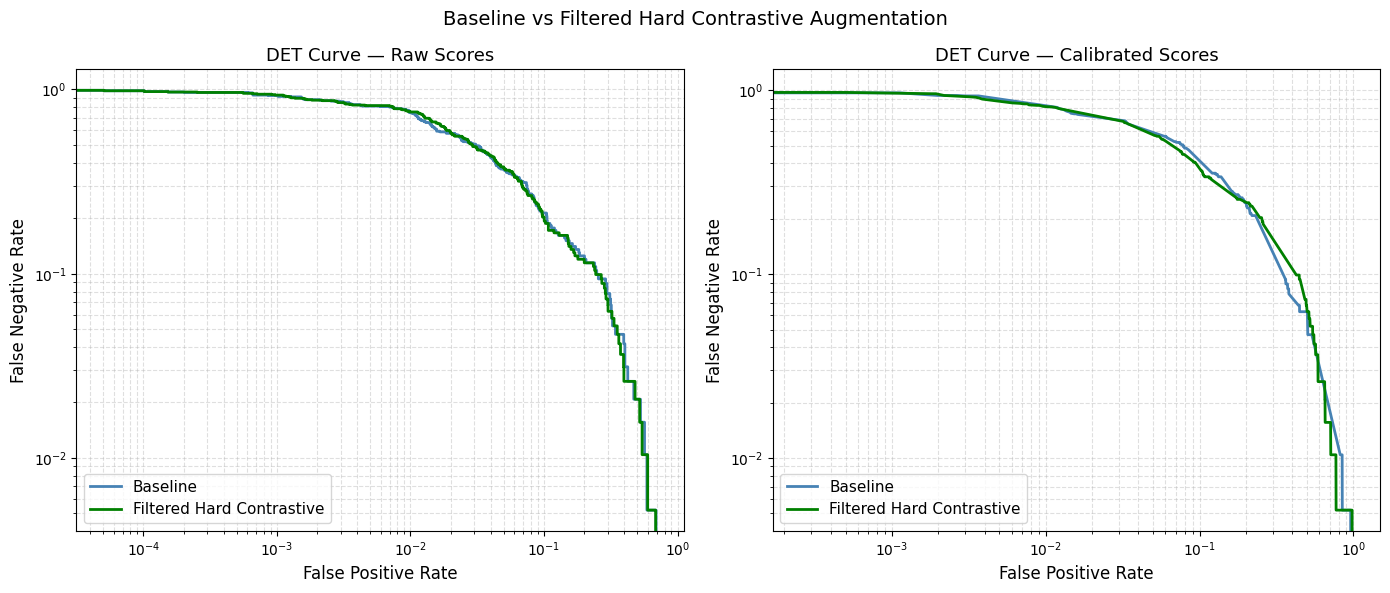

DET curves saved.


In [14]:
from sklearn.metrics import det_curve

# Save filtered hard contrastive metrics
hard_filt_metrics = {
    "filtered_hard_contrastive": {
        "raw": {
            "threshold": 0.5,
            "precision": round(precision_score(y_test, y_pred_hard_filt, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_hard_filt), 3),
            "f1": round(f1_score(y_test, y_pred_hard_filt, zero_division=0), 3),
        },
        "calibrated": {
            "threshold": round(t_hard_filt, 2),
            "precision": round(precision_score(y_test, y_pred_hard_filt_cal, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_hard_filt_cal), 3),
            "f1": round(f1_score(y_test, y_pred_hard_filt_cal, zero_division=0), 3),
        }
    }
}

with open("data/results/hard_contrastive_filtered_metrics.json", "w") as f:
    json.dump(hard_filt_metrics, f, indent=2)
print("Metrics saved.")

# DET curves
fpr_base, fnr_base, _ = det_curve(y_test, y_scores_base)
fpr_base_cal, fnr_base_cal, _ = det_curve(y_test, y_scores_base_cal)
fpr_hard_filt, fnr_hard_filt, _ = det_curve(y_test, y_scores_hard_filt)
fpr_hard_filt_cal, fnr_hard_filt_cal, _ = det_curve(y_test, y_scores_hard_filt_cal)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(fpr_base, fnr_base, color='steelblue', linewidth=2, label='Baseline')
ax1.plot(fpr_hard_filt, fnr_hard_filt, color='green', linewidth=2, label='Filtered Hard Contrastive')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('False Negative Rate', fontsize=12)
ax1.set_title('DET Curve — Raw Scores', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)

ax2.plot(fpr_base_cal, fnr_base_cal, color='steelblue', linewidth=2, label='Baseline')
ax2.plot(fpr_hard_filt_cal, fnr_hard_filt_cal, color='green', linewidth=2, label='Filtered Hard Contrastive')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('False Negative Rate', fontsize=12)
ax2.set_title('DET Curve — Calibrated Scores', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)

plt.suptitle('Baseline vs Filtered Hard Contrastive Augmentation', fontsize=14)
plt.tight_layout()
plt.savefig("data/results/hard_contrastive_filtered_det.png", dpi=150, bbox_inches='tight')
plt.show()
print("DET curves saved.")

In [15]:
with open("data/results/hard_contrastive_baseline_metrics.json") as f:
    m_base = json.load(f)["baseline"]
with open("data/results/hard_contrastive_unfiltered_metrics.json") as f:
    m_unfilt = json.load(f)["unfiltered_contrastive"]
with open("data/results/hard_contrastive_filtered_metrics.json") as f:
    m_filt = json.load(f)["filtered_hard_contrastive"]

rows = [
    {"condition": "Baseline",
     "precision_raw": m_base['raw']['precision'],
     "recall_raw": m_base['raw']['recall'],
     "f1_raw": m_base['raw']['f1'],
     "precision_cal": m_base['calibrated']['precision'],
     "recall_cal": m_base['calibrated']['recall'],
     "f1_cal": m_base['calibrated']['f1'],
     "threshold_cal": m_base['calibrated']['threshold']},
    {"condition": "Unfiltered Hard Contrastive",
     "precision_raw": m_unfilt['raw']['precision'],
     "recall_raw": m_unfilt['raw']['recall'],
     "f1_raw": m_unfilt['raw']['f1'],
     "precision_cal": m_unfilt['calibrated']['precision'],
     "recall_cal": m_unfilt['calibrated']['recall'],
     "f1_cal": m_unfilt['calibrated']['f1'],
     "threshold_cal": m_unfilt['calibrated']['threshold']},
    {"condition": "Filtered Hard Contrastive",
     "precision_raw": m_filt['raw']['precision'],
     "recall_raw": m_filt['raw']['recall'],
     "f1_raw": m_filt['raw']['f1'],
     "precision_cal": m_filt['calibrated']['precision'],
     "recall_cal": m_filt['calibrated']['recall'],
     "f1_cal": m_filt['calibrated']['f1'],
     "threshold_cal": m_filt['calibrated']['threshold']},
]

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv("data/results/hard_contrastive_augmentation_comparison.csv", index=False)
print(comparison_df.to_string(index=False))
print("\nSaved.")

                  condition  precision_raw  recall_raw  f1_raw  precision_cal  recall_cal  f1_cal  threshold_cal
                   Baseline          0.059       0.839   0.110          0.136       0.260   0.179           0.07
Unfiltered Hard Contrastive          0.059       0.839   0.111          0.120       0.219   0.155           0.11
  Filtered Hard Contrastive          0.059       0.833   0.110          0.173       0.167   0.170           0.13

Saved.
